# Seasonal Agriculture Performance Analysis

## Major Project – VOIS for Tech AICTE Batch 1 2026–2027

This project analyzes agricultural performance across different seasons, geographical areas, farming conditions, resource usage, and economic factors.

The objective is to identify seasonal patterns, trends, relationships, variations, and meaningful insights from the agricultural dataset.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [86]:
data = pd.read_csv("seasonal_agriculture_performance_dataset (3).csv")

In [87]:
data.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [88]:
data.shape

(4000, 28)

In [89]:
data.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [91]:
data.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [92]:
data.isnull().sum().sum()

np.int64(120)

In [93]:
data.duplicated().sum()

np.int64(0)

In [94]:
data.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## Missing Value Analysis

Before performing data cleaning, the dataset is examined to identify missing values and understand their distribution across important variables.

In [95]:
missing = data.isnull().sum()

missing[missing > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [96]:
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_percentage[missing_percentage > 0]

Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64

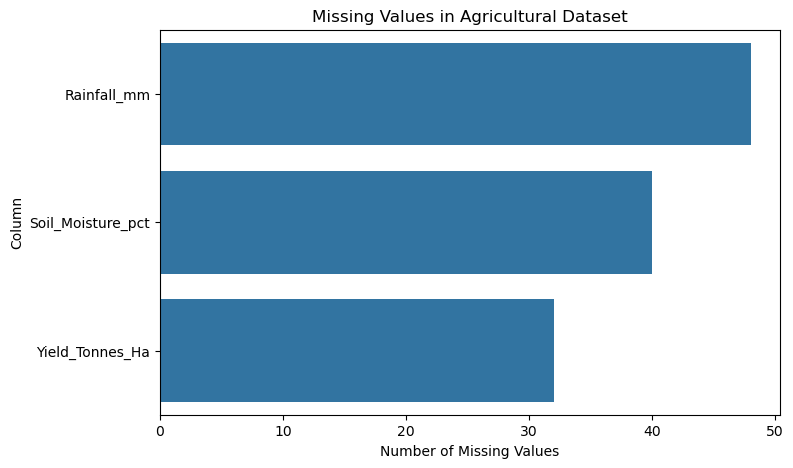

In [97]:
plt.figure(figsize=(8, 5))

missing_data = missing[missing > 0]

sns.barplot(
    x=missing_data.values,
    y=missing_data.index
)

plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.title("Missing Values in Agricultural Dataset")

plt.show()

In [98]:
data[data['Rainfall_mm'].isnull()].head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
186,SF10187,Tamil Nadu,Indore,Rice,Rabi,2.39,NaN,21.3,55.5,8.4,...,0.77,2.41,5.76,22588,171055,130107,-40948,3882,1.484,43.3
253,SF10254,Tamil Nadu,Ludhiana,Sugarcane,Zaid,5.93,NaN,33.3,61.0,9.4,...,0.83,62.76,372.17,3595,385870,1337951,952081,10283,36.193,58.7
271,SF10272,Karnataka,Erode,Groundnut,Kharif,6.25,NaN,33.0,76.6,7.6,...,0.74,0.45,2.81,57815,445735,162460,-283275,2848,0.987,44.8
272,SF10273,Punjab,Rajkot,Maize,Rabi,9.96,NaN,23.4,58.7,8.2,...,0.76,2.25,22.41,23140,591624,518567,-73057,7916,2.831,44.2
287,SF10288,Gujarat,Guntur,Wheat,Rabi,12.60,NaN,22.9,56.0,7.0,...,0.77,3.46,43.60,23714,689733,1033930,344197,5158,8.453,50.0


In [99]:
data[data['Rainfall_mm'].isnull()].head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
186,SF10187,Tamil Nadu,Indore,Rice,Rabi,2.39,NaN,21.3,55.5,8.4,...,0.77,2.41,5.76,22588,171055,130107,-40948,3882,1.484,43.3
253,SF10254,Tamil Nadu,Ludhiana,Sugarcane,Zaid,5.93,NaN,33.3,61.0,9.4,...,0.83,62.76,372.17,3595,385870,1337951,952081,10283,36.193,58.7
271,SF10272,Karnataka,Erode,Groundnut,Kharif,6.25,NaN,33.0,76.6,7.6,...,0.74,0.45,2.81,57815,445735,162460,-283275,2848,0.987,44.8
272,SF10273,Punjab,Rajkot,Maize,Rabi,9.96,NaN,23.4,58.7,8.2,...,0.76,2.25,22.41,23140,591624,518567,-73057,7916,2.831,44.2
287,SF10288,Gujarat,Guntur,Wheat,Rabi,12.60,NaN,22.9,56.0,7.0,...,0.77,3.46,43.60,23714,689733,1033930,344197,5158,8.453,50.0


In [100]:
data[data['Yield_Tonnes_Ha'].isnull()].head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
55,SF10056,Karnataka,Warangal,Groundnut,Rabi,11.70,167.3,26.2,62.4,6.8,...,0.94,NaN,19.42,50837,780159,987255,207096,4665,4.163,39.4
163,SF10164,Madhya Pradesh,Erode,Pulses,Zaid,3.55,445.9,29.7,61.1,8.2,...,0.89,NaN,1.06,58920,206701,62455,-144246,1837,0.577,44.3
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
648,SF10649,Andhra Pradesh,Krishna,Groundnut,Rabi,6.14,423.1,22.2,53.4,7.0,...,0.86,NaN,8.66,61086,386561,529005,142444,3692,2.346,31.2
650,SF10651,Gujarat,Raichur,Maize,Rabi,13.23,587.6,24.7,59.3,8.4,...,0.76,NaN,11.77,21564,1065547,253808,-811739,9310,1.264,52.4


In [101]:
missing_by_season = data.groupby('Season')[
    ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
].apply(lambda x: x.isnull().sum())

missing_by_season

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
Season,,,
Kharif,19,18,7
Rabi,18,13,20
Zaid,11,9,5


In [102]:
data['Rainfall_mm'] = data['Rainfall_mm'].fillna(
    data['Rainfall_mm'].median()
)

data['Soil_Moisture_pct'] = data['Soil_Moisture_pct'].fillna(
    data['Soil_Moisture_pct'].median()
)

data['Yield_Tonnes_Ha'] = data['Yield_Tonnes_Ha'].fillna(
    data['Yield_Tonnes_Ha'].median()
)

In [103]:
data.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

### Data Cleaning Result

Missing values in the numerical columns were handled using median imputation. After cleaning, the dataset contains no missing values.

## Outlier Analysis

Outlier analysis is performed to identify unusually high or low observations in important numerical variables. Outliers are investigated before deciding whether they should be retained or removed.

In [104]:
numeric_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Seed_Quality_Score',
    'Disease_Pest_Risk_pct',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]

In [105]:
outlier_summary = {}

for column in numeric_columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    outlier_summary[column] = len(outliers)

outlier_summary

{'Rainfall_mm': 0,
 'Avg_Temperature_C': 2,
 'Humidity_pct': 6,
 'Soil_pH': 0,
 'Soil_Moisture_pct': 5,
 'Nitrogen_kg_ha': 10,
 'Phosphorus_kg_ha': 16,
 'Potassium_kg_ha': 32,
 'Fertilizer_kg_ha': 15,
 'Pesticide_Litre_ha': 8,
 'Water_Used_m3': 276,
 'Yield_Tonnes_Ha': 302,
 'Production_Tonnes': 333,
 'Seed_Quality_Score': 0,
 'Disease_Pest_Risk_pct': 10,
 'Market_Price_INR_Tonne': 0,
 'Total_Cost_INR': 0,
 'Revenue_INR': 240,
 'Profit_INR': 404}

In [106]:
outlier_summary_df = pd.DataFrame(
    list(outlier_summary.items()),
    columns=['Column', 'Outlier_Count']
)

outlier_summary_df = outlier_summary_df.sort_values(
    by='Outlier_Count',
    ascending=False
)

outlier_summary_df

,Column,Outlier_Count
18,Profit_INR,404
12,Production_Tonnes,333
11,Yield_Tonnes_Ha,302
10,Water_Used_m3,276
17,Revenue_INR,240
7,Potassium_kg_ha,32
6,Phosphorus_kg_ha,16
8,Fertilizer_kg_ha,15
14,Disease_Pest_Risk_pct,10
5,Nitrogen_kg_ha,10


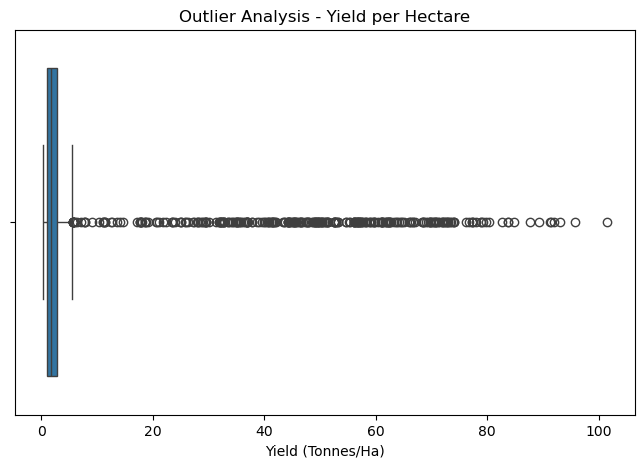

In [107]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=data['Yield_Tonnes_Ha'])

plt.title('Outlier Analysis - Yield per Hectare')
plt.xlabel('Yield (Tonnes/Ha)')

plt.show()

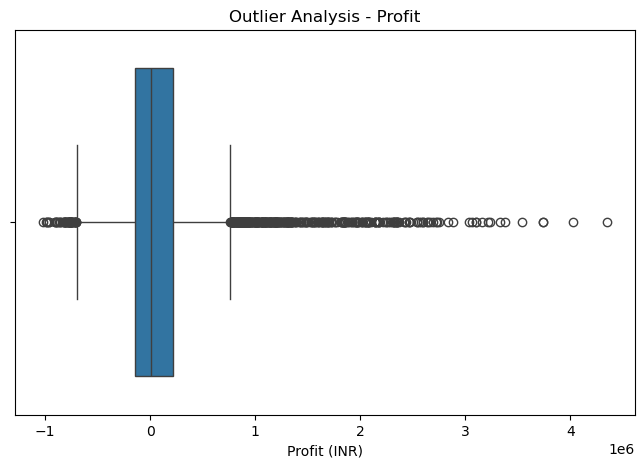

In [108]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=data['Profit_INR'])

plt.title('Outlier Analysis - Profit')
plt.xlabel('Profit (INR)')

plt.show()

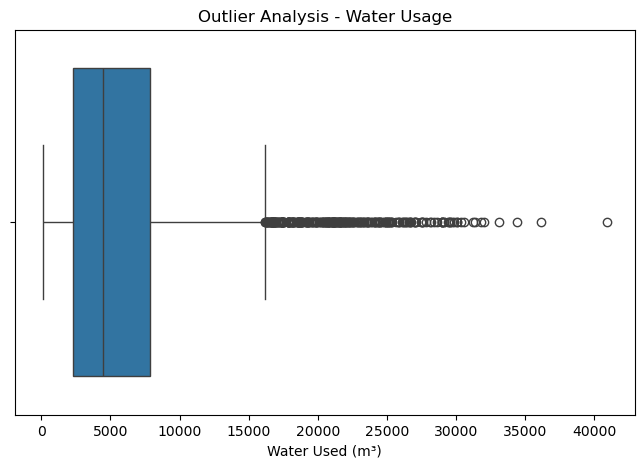

In [109]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=data['Water_Used_m3'])

plt.title('Outlier Analysis - Water Usage')
plt.xlabel('Water Used (m³)')

plt.show()

## Data Validation

The cleaned dataset is validated by checking categorical values, numerical ranges, and seasonal distributions to ensure that the data is suitable for further analysis.

In [110]:
data['Season'].value_counts()


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [111]:
data['Crop'].value_counts()

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

In [112]:

data['State'].value_counts()

State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

In [113]:
data['Irrigation_Method'].value_counts()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

In [114]:
data[numeric_columns].min()

Rainfall_mm                    80.00
Avg_Temperature_C              16.20
Humidity_pct                   25.00
Soil_pH                         5.20
Soil_Moisture_pct               8.00
Nitrogen_kg_ha                 40.00
Phosphorus_kg_ha               15.00
Potassium_kg_ha                30.00
Fertilizer_kg_ha               40.00
Pesticide_Litre_ha              0.50
Water_Used_m3                 128.00
Yield_Tonnes_Ha                 0.30
Production_Tonnes               0.15
Seed_Quality_Score              0.65
Disease_Pest_Risk_pct           5.00
Market_Price_INR_Tonne       2594.00
Total_Cost_INR              26826.00
Revenue_INR                  6107.00
Profit_INR               -1019223.00
dtype: float64

In [115]:
data[numeric_columns].max()

Rainfall_mm                  1395.20
Avg_Temperature_C              39.70
Humidity_pct                   95.00
Soil_pH                         8.40
Soil_Moisture_pct              47.00
Nitrogen_kg_ha                220.00
Phosphorus_kg_ha              120.00
Potassium_kg_ha               200.00
Fertilizer_kg_ha              400.00
Pesticide_Litre_ha             12.08
Water_Used_m3               40902.00
Yield_Tonnes_Ha               101.44
Production_Tonnes            1424.40
Seed_Quality_Score              1.00
Disease_Pest_Risk_pct          88.90
Market_Price_INR_Tonne     131240.00
Total_Cost_INR            1349990.00
Revenue_INR               5080900.00
Profit_INR                4345421.00
dtype: float64

In [116]:
pd.crosstab(data['Season'], data['Crop'])

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


In [117]:
pd.crosstab(data['Season'], data['Irrigation_Method'])

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


## Seasonal Performance Analysis

This section compares agricultural performance across Kharif, Rabi, and Zaid seasons using yield, production, revenue, and profit.

In [118]:
season_performance = data.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Profit_INR']
].mean()

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Season,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555
Rabi,5.039435,41.486712,601526.048556,87689.470191
Zaid,4.641313,38.886111,519171.904040,-24804.824916


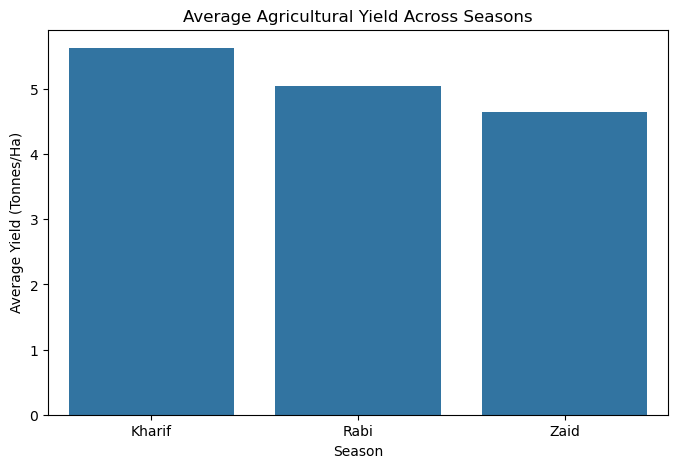

In [119]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_performance.index,
    y=season_performance['Yield_Tonnes_Ha']
)

plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.title('Average Agricultural Yield Across Seasons')

plt.show()

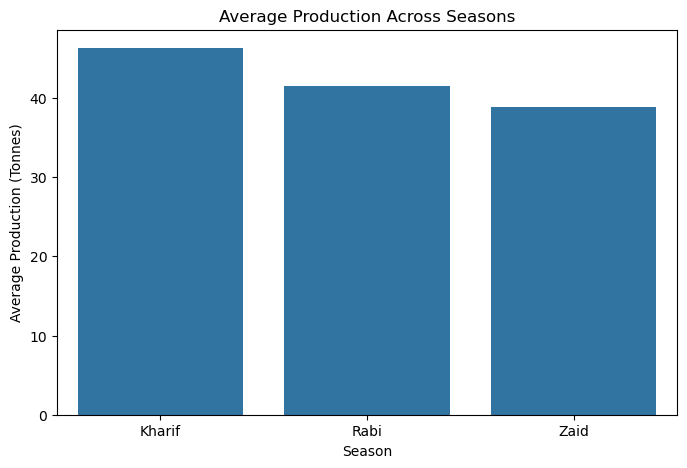

In [120]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_performance.index,
    y=season_performance['Production_Tonnes']
)

plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.title('Average Production Across Seasons')

plt.show()

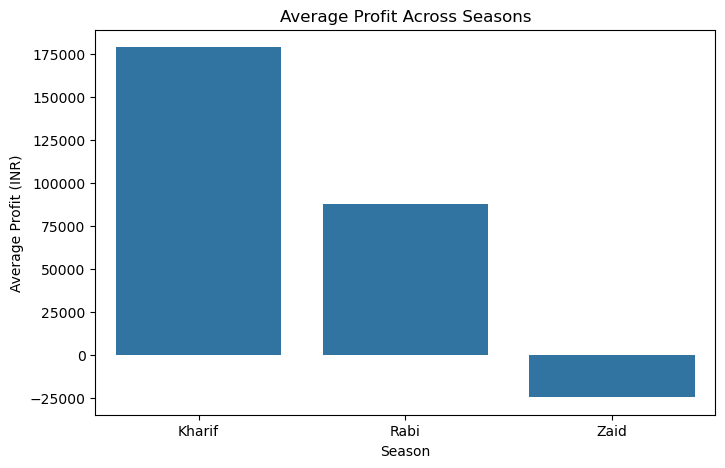

In [121]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_performance.index,
    y=season_performance['Profit_INR']
)

plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.title('Average Profit Across Seasons')

plt.show()

## Seasonal Environmental Conditions

This analysis examines how environmental conditions such as rainfall, temperature, humidity, and sunlight vary across different agricultural seasons.

In [122]:
season_environment = data.groupby('Season')[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day'
    ]
].mean()

season_environment

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,849.199663,28.454019,71.812591,6.793367
Rabi,437.615366,23.489183,57.893178,7.589797
Zaid,304.654714,31.042088,52.012121,8.178788


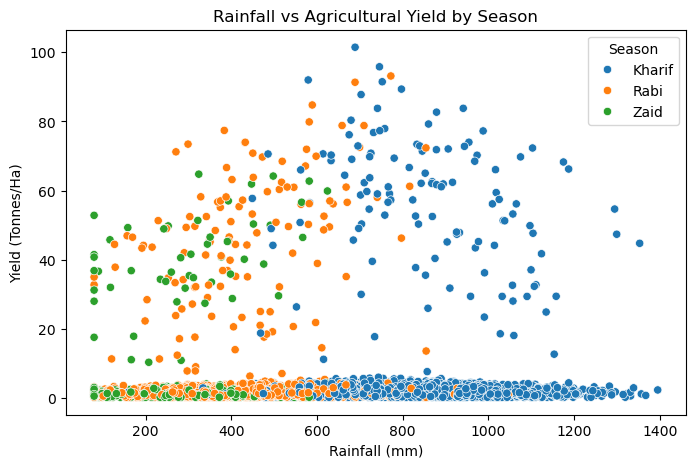

In [123]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Rainfall vs Agricultural Yield by Season')

plt.show()

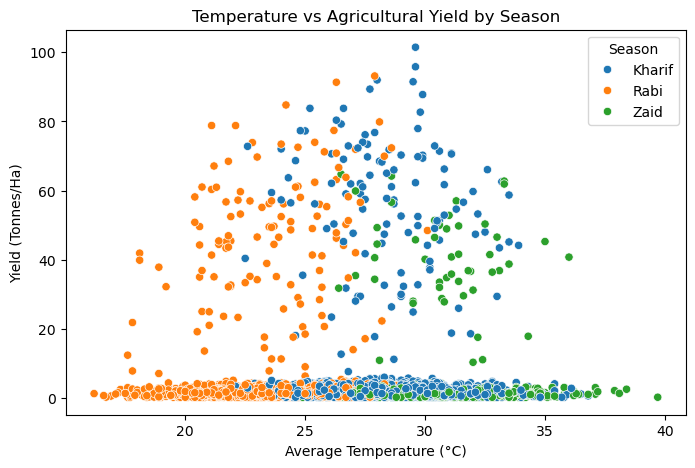

In [124]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Temperature vs Agricultural Yield by Season')

plt.show()

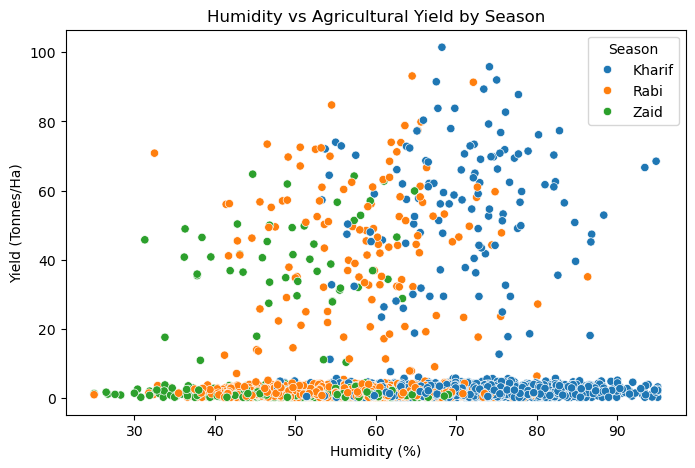

In [125]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='Humidity_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.xlabel('Humidity (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Humidity vs Agricultural Yield by Season')

plt.show()

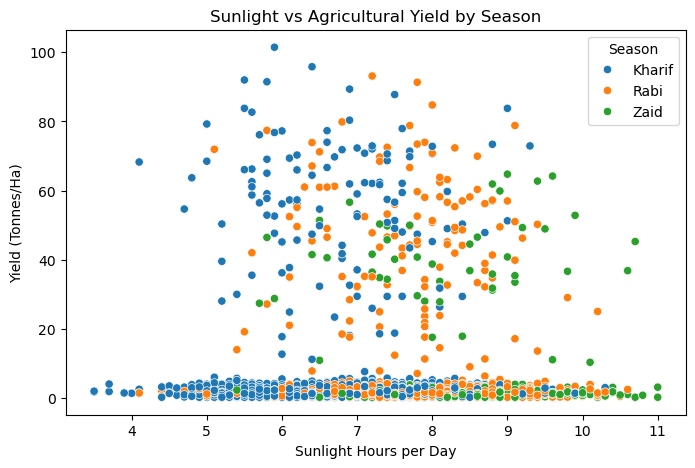

In [126]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='Sunlight_Hours_Day',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.xlabel('Sunlight Hours per Day')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Sunlight vs Agricultural Yield by Season')

plt.show()

## Seasonal Resource Usage Analysis

This analysis compares the average use of water, fertilizer, and pesticide across different agricultural seasons.

In [127]:
resource_usage = data.groupby('Season')[
    ['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']
].mean()

resource_usage

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,
Kharif,6102.201237,187.077965,5.079747
Rabi,5846.987093,185.407068,5.024690
Zaid,6419.893939,184.638047,5.171212


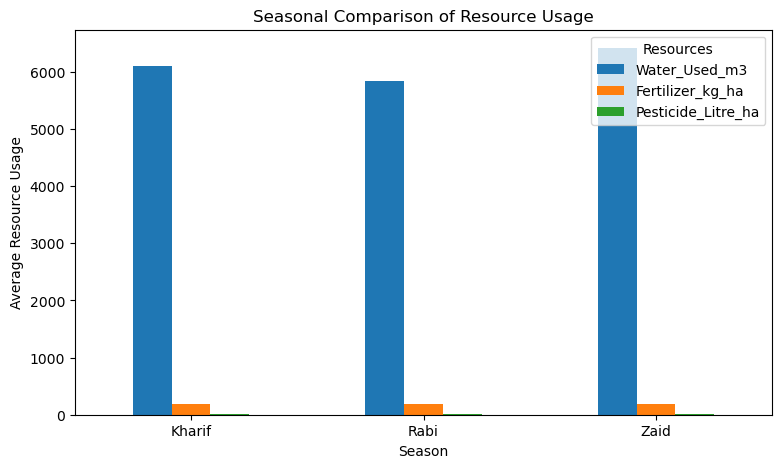

In [128]:
resource_usage.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.xlabel('Season')
plt.ylabel('Average Resource Usage')
plt.title('Seasonal Comparison of Resource Usage')
plt.xticks(rotation=0)
plt.legend(title='Resources')

plt.show()

## Key Insights

The analysis of seasonal agricultural data reveals several important patterns and relationships related to agricultural performance, environmental conditions, and resource usage.

In [129]:
season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Season,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555
Rabi,5.039435,41.486712,601526.048556,87689.470191
Zaid,4.641313,38.886111,519171.904040,-24804.824916


In [130]:
resource_usage

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,
Kharif,6102.201237,187.077965,5.079747
Rabi,5846.987093,185.407068,5.024690
Zaid,6419.893939,184.638047,5.171212


In [131]:
correlation = data[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_Moisture_pct',
        'Water_Used_m3',
        'Yield_Tonnes_Ha',
        'Profit_INR'
    ]
].corr()

correlation['Yield_Tonnes_Ha'].sort_values(ascending=False)

Yield_Tonnes_Ha       1.000000
Profit_INR            0.488466
Water_Used_m3         0.386294
Rainfall_mm           0.030951
Humidity_pct          0.012297
Soil_Moisture_pct     0.010999
Avg_Temperature_C     0.009996
Sunlight_Hours_Day   -0.015341
Name: Yield_Tonnes_Ha, dtype: float64

## Key Insights

The analysis reveals the following key insights from the seasonal agricultural data:

1. **Kharif season shows the highest overall agricultural performance**, with the highest average yield (5.63 tonnes/ha), production (46.31 tonnes), revenue (₹7.11 lakh), and profit (₹1.79 lakh).

2. **Rabi season shows moderate agricultural performance**, with an average yield of 5.04 tonnes/ha and average profit of approximately ₹87,689.

3. **Zaid season records the lowest performance**, with the lowest average yield (4.64 tonnes/ha), production (38.89 tonnes), revenue (₹5.19 lakh), and a negative average profit of approximately ₹24,805.

4. **Water usage is highest during the Zaid season**, averaging 6,419.89 m³, even though its average yield is the lowest among the three seasons.

5. **Profit has the strongest positive correlation with yield (0.48)** among the analyzed factors, followed by water usage (0.39). Rainfall, humidity, soil moisture, temperature, and sunlight show very weak linear correlations with yield in this dataset.

## Data-Driven Recommendations

Based on the analysis, the following recommendations can be made:

1. **Focus on Kharif-season opportunities:** Since Kharif shows the highest average yield, production, revenue, and profit, agricultural planning can prioritize suitable crops and farming practices during this season.

2. **Improve Zaid-season resource efficiency:** Zaid uses the highest average water while producing the lowest average yield. Improving irrigation efficiency and water management should therefore be considered.

3. **Review Zaid-season profitability:** Since the average profit during Zaid is negative, farmers and planners should evaluate production costs, expected market prices, and resource requirements before expanding cultivation during this season.

4. **Optimize resource allocation:** Water, fertilizer, and pesticide usage should be planned according to seasonal requirements rather than applying uniform resource levels across all seasons.

5. **Use yield-focused planning:** Since yield has a moderate positive relationship with profit, improving productivity while controlling production costs may contribute to better economic outcomes.

## Conclusion

This project analyzed agricultural performance across Kharif, Rabi, and Zaid seasons using production, yield, resource usage, environmental factors, and economic indicators.

The analysis showed that Kharif recorded the strongest overall performance, while Zaid showed lower yield and negative average profit despite higher water usage. The findings demonstrate that seasonal conditions and resource utilization are important factors to consider when evaluating agricultural performance.

The analysis provides evidence-based insights that can support better seasonal planning, resource management, and agricultural decision-making.

## Final Project Summary

This project demonstrates the use of Python-based data analytics to explore seasonal agricultural performance. The analysis includes data cleaning, validation, exploratory analysis, correlation analysis, visualization, interpretation, and data-driven recommendations.